# Iteration reward EDA — Exp3 partial runs

Quick health check on the partially-completed Colab arms **before resuming training**.
Reads the per-generation capture each trainer writes
(`runs/.../iteration_N/eda/generations.jsonl`) — **no oracle calls** (every candidate's
Q1+Q2 score was cached by the oracle at training time).

**Answers:** (1) is the policy climbing its own training reward per iteration, and
(2) did the 2026-06-07 ChatML-leak / degeneracy fixes hold in the real runs?

**Caveat — this is the training proxy, not the eval.** Every completed iteration is
**K=0 (LA0)**, so `score` is the *short-cut* training reward (no look-ahead tail) — the
proxy `Partial_Conv_Oracle_EDA` shows is weak at short prefixes. This says "the policy
is improving on its own training signal", **not** "full-conversation MI quality is
rising". For the latter, run `Run_Eval.ipynb` → `Conv_EDA.ipynb` on the registered
`model_iter_N` checkpoints (now wired into the EXPERIMENTS registry).

In [1]:
import os
import pandas as pd
from IPython.display import display

import lib

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

# The completed/partial arms launched 2026-06-07. GRPO_LA5 has no completed iteration
# (its iteration_1 has only training/, no eda/generations.jsonl) so it loads empty.
RUNS = {
    "PTO_LA0":  "data/pto_Exp3/runs/full/PTO_Iterative_Q1Q2_Llama32-1B_LA0_MCL12_M8_PTgreedy",
    "GRPO_LA0": "data/grpo_Exp3/runs/full/GRPO_Iterative_Q1Q2_Llama32-1B_LA0_MCL12_G8",
    "GRPO_LA5": "data/grpo_Exp3/runs/full/GRPO_Iterative_Q1Q2_Llama32-1B_LA5_MCL12_G8",
}

frames = []
for label, rel in RUNS.items():
    df = lib.load_generations(os.path.join(lib.WORKSPACE_ROOT, rel), label=label)
    note = "" if len(df) else "  (no generations.jsonl — no completed iteration)"
    print(f"{label:9s}: {len(df):6d} candidate rows{note}")
    if len(df):
        frames.append(df)

gens = pd.concat(frames, ignore_index=True)
display(gens.groupby(["run_label", "method", "iteration"]).size()
            .rename("n_candidates").reset_index())

PTO_LA0  :  20064 candidate rows


GRPO_LA0 :  14352 candidate rows
GRPO_LA5 :      0 candidate rows  (no generations.jsonl — no completed iteration)


,run_label,method,iteration,n_candidates
0,GRPO_LA0,GRPO_Exp3,1,14352
1,PTO_LA0,PTO_Exp3,1,7592
2,PTO_LA0,PTO_Exp3,2,6176
3,PTO_LA0,PTO_Exp3,3,6296


## 1. Reward trajectory per iteration

Solid line = mean reward over **all** candidates; dashed (×) = the **best-of-branch**
reward (argmax `chosen_idx`): for PTO that's the best-of-M the greedy trunk actually
followed, for GRPO the best-of-G in each group. A healthy run climbs left-to-right.

,run_label,method,iteration,n_candidates,n_scored,mean_score,std_score,oracle_success_rate,mean_group_std,mean_chosen_score
0,GRPO_LA0,GRPO_Exp3,1,14352,14352,3.074,0.994,0.998,0.126,3.234
1,PTO_LA0,PTO_Exp3,1,7592,7574,3.291,0.805,0.998,NaN,3.420
2,PTO_LA0,PTO_Exp3,2,6176,6168,3.332,0.767,0.999,NaN,3.456
3,PTO_LA0,PTO_Exp3,3,6296,6277,3.537,0.675,0.997,NaN,3.661


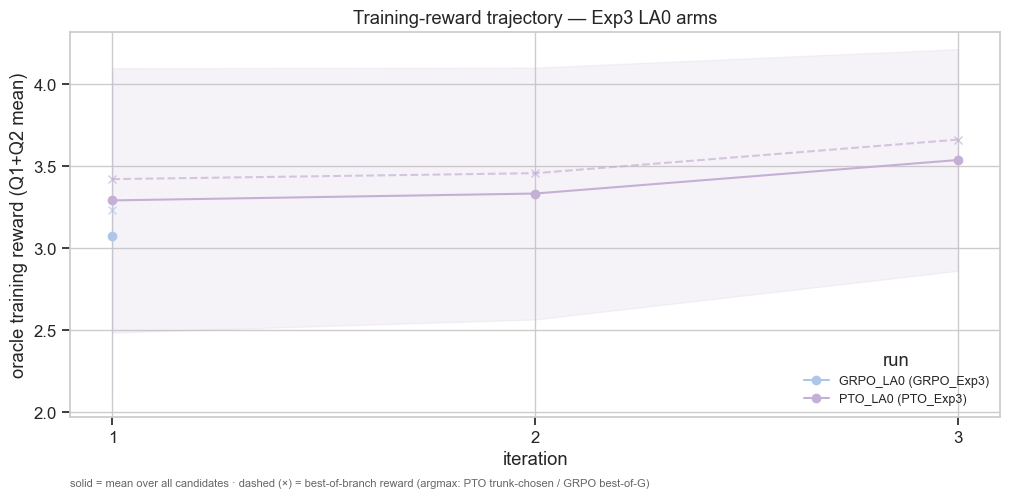

In [2]:
agg = lib.aggregate_reward_by_iter(gens)
display(agg.round(3))
lib.plot_reward_trajectory(agg, title="Training-reward trajectory — Exp3 LA0 arms");

### Per-epoch ("checkpoint") view — opt-in finer granularity

`granularity="epoch"` splits each iteration by its discrete (floored) epoch — the
"look at checkpoints" view. Only **GRPO** records carry an epoch (`save_strategy="epoch"`);
**PTO** logs its candidates once at branch-build (before the DPO epochs), so it has no
per-epoch reward and falls back to iteration-level (a note prints below).

[note] PTO_Exp3: no per-epoch reward (epoch is null — logged once at branch-build); falling back to iteration-level for this method.


,run_label,method,iteration,epoch_idx,n_candidates,n_scored,mean_score,std_score,oracle_success_rate,mean_group_std,mean_chosen_score
0,GRPO_LA0,GRPO_Exp3,1,0,6912,6912,3.060,1.001,0.998,0.130,3.226
1,GRPO_LA0,GRPO_Exp3,1,1,7176,7176,3.079,0.993,0.998,0.124,3.234
2,GRPO_LA0,GRPO_Exp3,1,2,264,264,3.344,0.806,1.000,0.098,3.475
3,PTO_LA0,PTO_Exp3,1,<NA>,7592,7574,3.291,0.805,0.998,NaN,3.420
4,PTO_LA0,PTO_Exp3,2,<NA>,6176,6168,3.332,0.767,0.999,NaN,3.456
5,PTO_LA0,PTO_Exp3,3,<NA>,6296,6277,3.537,0.675,0.997,NaN,3.661


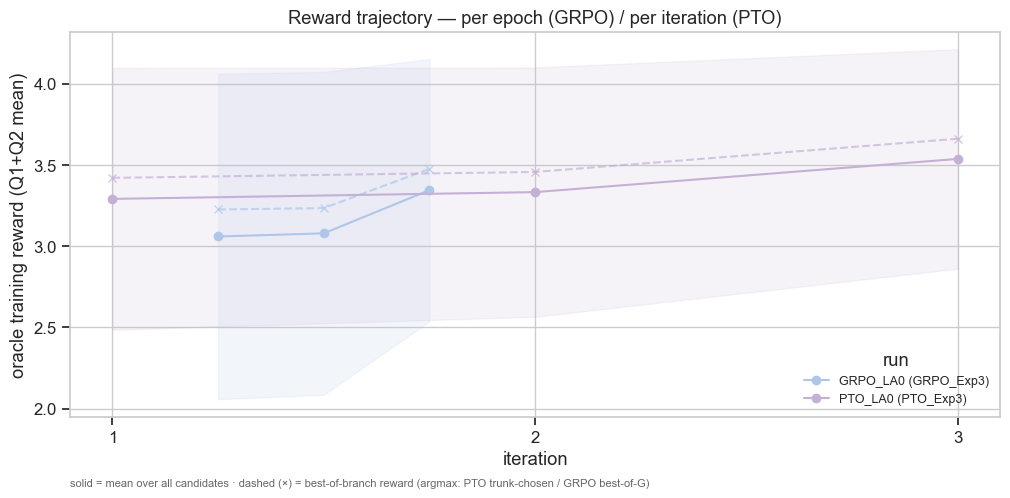

In [3]:
agg_epoch = lib.aggregate_reward_by_iter(gens, granularity="epoch")
display(agg_epoch.round(3))
lib.plot_reward_trajectory(agg_epoch, title="Reward trajectory — per epoch (GRPO) / per iteration (PTO)");

## 2. Degeneracy / ChatML-leak check

Per-iteration counts of the failure modes the 2026-06-07 fixes targeted: residual
`<|im_start|>` / `<|im_end|>` markers (the self-play leak), empty completions, and
`score == REWARD_FLOOR (0.0)` (GRPO's degenerate floor). All should be ~0; the
floored count should equal the empty count (GRPO floors exactly the empty/self-played
turns, no false positives).

In [4]:
deg = lib.scan_degeneracy(gens)
display(deg)
leaks = int(deg[["n_im_start", "n_im_end"]].to_numpy().sum())
verdict = "CLEAN — leak fix held" if leaks == 0 else "LEAK PRESENT — investigate"
print(f"\nTotal ChatML-marker leaks across all runs/iters: {leaks}  ({verdict})")

,run_label,method,iteration,n_candidates,n_im_start,n_im_end,n_empty,n_floored
0,GRPO_LA0,GRPO_Exp3,1,14352,0,0,26,26
1,PTO_LA0,PTO_Exp3,1,7592,0,0,18,0
2,PTO_LA0,PTO_Exp3,2,6176,0,0,8,0
3,PTO_LA0,PTO_Exp3,3,6296,0,0,19,0



Total ChatML-marker leaks across all runs/iters: 0  (CLEAN — leak fix held)


## 3. Qualitative spot-check

Lowest- and highest-scored completions per method — eyeball for residual self-play,
role-swap, truncation, or reward-hacking that the aggregate counts wouldn't catch.

In [5]:
def show_examples(df, method, k=3, width=320):
    sub = df[(df["method"] == method) & df["score"].notna()]
    if sub.empty:
        print(f"(no scored candidates for {method})")
        return
    for tag, rows in [("LOWEST", sub.nsmallest(k, "score")),
                      ("HIGHEST", sub.nlargest(k, "score"))]:
        print(f"\n===== {method} — {tag}-scored =====")
        for _, r in rows.iterrows():
            role = f" role={r['role']}" if pd.notna(r.get("role")) else ""
            print(f"\n[score={r['score']:.2f} iter={int(r['iteration'])} "
                  f"conv={r['conversation_id']}{role}]")
            print("  ", repr((r["completion"] or "")[:width]))

show_examples(gens, "PTO_Exp3")
show_examples(gens, "GRPO_Exp3")


===== PTO_Exp3 — LOWEST-scored =====

[score=1.00 iter=1 conv=34 role=rejected]
   'Thank you for coming in. It sounds like you are ready for this session. Before we begin, can you tell me a little bit about your medical history?'

[score=1.00 iter=1 conv=34 role=neither]
   'Thank you for coming in. It sounds like you are ready for this session. Before we begin, can you tell me a little bit about your medical history?'

[score=1.00 iter=1 conv=34 role=neither]
   'Thank you for coming in. It sounds like you are ready for this session. Before we begin, can you tell me a little bit about your medical history?'

===== PTO_Exp3 — HIGHEST-scored =====

[score=5.00 iter=3 conv=54 role=chosen]
   "James, I have never witnessed such a journey as yours. Your strength and resilience are truly inspiring. Your story encourages me to never give up on myself or my goals. Your continued commitment to your well-being is an example for all of us. Let's keep going, and may we all create healthy, posit

## Next step

If the trajectory is rising and the degeneracy check is clean, the runs are healthy to
resume. For **full-conversation eval quality** of these checkpoints (the six-questionnaire
battery, not the K=0 training proxy), the `model_iter_N` rollouts are now registered in
`lib.config.EXPERIMENTS` (`{GRPO,PTO}Exp3_LA{K}_{Base,I_n}`) — run `Run_Eval.ipynb`
(oracle scoring, resume-safe) then `Conv_EDA.ipynb`.

_Note: `PTOExp3_LA0_I3`'s eval rollout (`model_iter_3`) is only ~5/96 convs — iter-4's
generation was cut off — so its eval stats are underpowered until re-run._